# HyConEx from scratch sur Iris

Ce notebook:
- entraîne un modèle HyConEx-like sur Iris,
- affiche les métriques et courbes d'apprentissage,
- prend ~10 exemples aléatoires du test,
- génère les contre-factuels vers chaque classe cible,
- montre les changements de features nécessaires pour atteindre chaque classe.

In [1]:
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
# Chargement Iris
iris = load_iris()
X_raw = iris.data.astype(np.float32)
y = iris.target.astype(np.int64)
feature_names = iris.feature_names
class_names = iris.target_names

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=SEED, stratify=y
)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

# Mise à l'échelle [0, 1] pour faciliter la génération CF avec clamp
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val = scaler.transform(X_val_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print('Shapes:')
print('train:', X_train.shape, y_train.shape)
print('val  :', X_val.shape, y_val.shape)
print('test :', X_test.shape, y_test.shape)

Shapes:
train: (84, 4) (84,)
val  : (21, 4) (21,)
test : (45, 4) (45,)


In [3]:
@dataclass
class TrainConfig:
    epochs: int = 140
    batch_size: int = 16
    lr: float = 2e-3
    weight_decay: float = 1e-5
    latent_dim: int = 32
    hidden_dim: int = 64
    cf_lambda: float = 0.35
    l1_lambda: float = 0.01
    l2_lambda: float = 0.005


class HyConExFromScratch(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, latent_dim: int, hidden_dim: int):
        super().__init__()
        self.input_dim = input_dim
        self.num_classes = num_classes
        self.latent_dim = latent_dim

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )

        self.hyper = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes * (latent_dim + 1)),
        )

        self.cf_generator = nn.Sequential(
            nn.Linear(latent_dim + num_classes, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Tanh(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        params = self.hyper(z).view(-1, self.num_classes, self.latent_dim + 1)
        w = params[:, :, :self.latent_dim]
        b = params[:, :, self.latent_dim]
        logits = torch.einsum('bcd,bd->bc', w, z) + b
        return logits

    def generate_counterfactual(self, x: torch.Tensor, y_target: torch.Tensor) -> torch.Tensor:
        z = self.encoder(x)
        t_oh = F.one_hot(y_target, num_classes=self.num_classes).float()
        cf_in = torch.cat([z, t_oh], dim=1)
        delta = self.cf_generator(cf_in)
        return torch.clamp(x + delta, 0.0, 1.0)


def sample_alternative_targets(yb: torch.Tensor, num_classes: int) -> torch.Tensor:
    noise = torch.randint(1, num_classes, size=yb.shape, device=yb.device)
    return (yb + noise) % num_classes


def predict(model: nn.Module, X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X, dtype=torch.float32, device=device)
        logits = model(xt)
        proba = torch.softmax(logits, dim=1).cpu().numpy()
        y_pred = np.argmax(proba, axis=1)
    return y_pred, proba


cfg = TrainConfig()
num_classes = len(np.unique(y_train))
model = HyConExFromScratch(input_dim=X_train.shape[1], num_classes=num_classes, latent_dim=cfg.latent_dim, hidden_dim=cfg.hidden_dim).to(device)
optim = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)),
    batch_size=cfg.batch_size,
    shuffle=True,
)

history = []
best_val_acc = -1.0
best_state = None

for epoch in range(1, cfg.epochs + 1):
    model.train()
    running_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        y_target = sample_alternative_targets(yb, num_classes)

        logits = model(xb)
        ce = F.cross_entropy(logits, yb)

        x_cf = model.generate_counterfactual(xb, y_target)
        ce_cf = F.cross_entropy(model(x_cf), y_target)
        delta = x_cf - xb
        l1 = delta.abs().mean()
        l2 = (delta ** 2).mean()

        loss = ce + cfg.cf_lambda * ce_cf + cfg.l1_lambda * l1 + cfg.l2_lambda * l2
        optim.zero_grad()
        loss.backward()
        optim.step()
        running_loss += loss.item() * xb.shape[0]

    train_loss = running_loss / len(X_train)
    y_val_pred, _ = predict(model, X_val)
    val_acc = accuracy_score(y_val, y_val_pred)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_accuracy': val_acc, 'best_val_accuracy': best_val_acc})

if best_state is not None:
    model.load_state_dict(best_state)
    model.to(device)

history_df = pd.DataFrame(history)
history_df.tail()

,epoch,train_loss,val_accuracy,best_val_accuracy
135,136,0.025350,1.0,1.0
136,137,0.028030,1.0,1.0
137,138,0.023294,1.0,1.0
138,139,0.021473,1.0,1.0
139,140,0.020210,1.0,1.0


In [4]:
# Metriques finales
y_test_pred, proba_test = predict(model, X_test)
acc_test = accuracy_score(y_test, y_test_pred)
print(f'Accuracy test: {acc_test:.4f}')

report = classification_report(y_test, y_test_pred, target_names=class_names, output_dict=True, digits=4)
report_df = pd.DataFrame(report).T
report_df

Accuracy test: 0.9333


,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,0.833333,1.000000,0.909091,15.000000
virginica,1.000000,0.800000,0.888889,15.000000
accuracy,0.933333,0.933333,0.933333,0.933333
macro avg,0.944444,0.933333,0.932660,45.000000
weighted avg,0.944444,0.933333,0.932660,45.000000


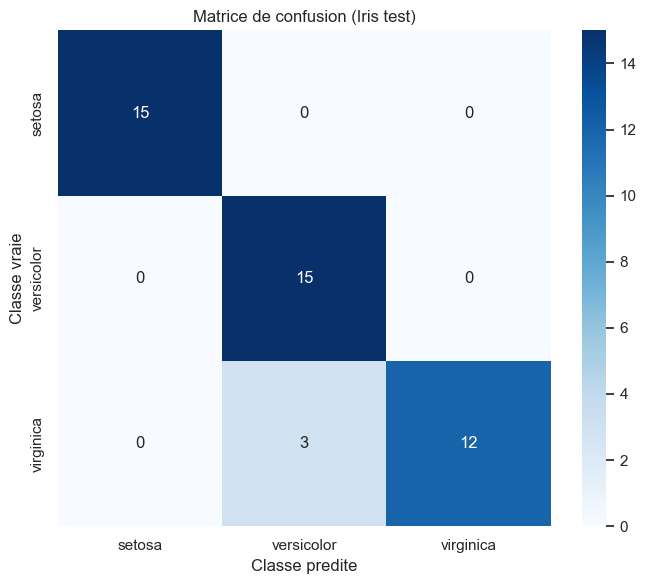

In [5]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title('Matrice de confusion (Iris test)')
plt.xlabel('Classe predite')
plt.ylabel('Classe vraie')
plt.tight_layout()
plt.show()

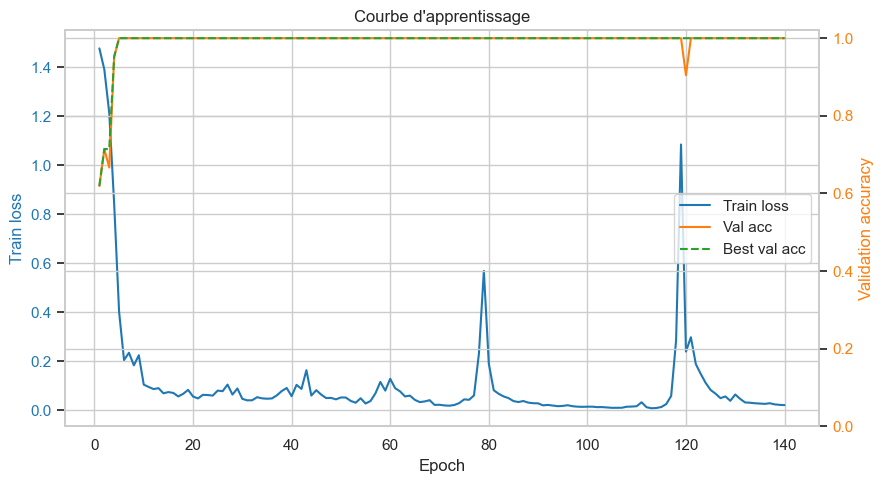

In [6]:
# Courbes d'apprentissage
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(history_df['epoch'], history_df['train_loss'], color='tab:blue', label='Train loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train loss', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(history_df['epoch'], history_df['val_accuracy'], color='tab:orange', label='Val acc')
ax2.plot(history_df['epoch'], history_df['best_val_accuracy'], color='tab:green', linestyle='--', label='Best val acc')
ax2.set_ylabel('Validation accuracy', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.set_ylim(0, 1.02)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title('Courbe d\'apprentissage')
plt.tight_layout()
plt.show()

## Contre-factuels sur ~10 exemples aléatoires

Pour chaque exemple, on génère un contre-factuel vers **chaque classe cible** (0, 1, 2).  
On affiche ensuite les changements nécessaires sur les variables Iris:
- sepal length,
- sepal width,
- petal length,
- petal width.

In [7]:
def cf_for_all_targets(x_scaled_row: np.ndarray, y_true: int):
    x_in = torch.tensor(x_scaled_row.reshape(1, -1), dtype=torch.float32, device=device)
    rows = []
    with torch.no_grad():
        y_orig_pred = int(torch.argmax(model(x_in), dim=1).item())
        x_orig_raw = scaler.inverse_transform(x_scaled_row.reshape(1, -1))[0]

        for target in range(len(class_names)):
            yt = torch.tensor([target], dtype=torch.long, device=device)
            x_cf = model.generate_counterfactual(x_in, yt)
            y_cf_pred = int(torch.argmax(model(x_cf), dim=1).item())
            valid = (y_cf_pred == target)

            x_cf_scaled = x_cf.cpu().numpy()[0]
            x_cf_raw = scaler.inverse_transform(x_cf_scaled.reshape(1, -1))[0]
            delta_raw = x_cf_raw - x_orig_raw
            l1_raw = float(np.abs(delta_raw).sum())

            feature_changes = []
            for fname, before, after, d in zip(feature_names, x_orig_raw, x_cf_raw, delta_raw):
                feature_changes.append({
                    'feature': fname,
                    'from': float(before),
                    'to': float(after),
                    'delta': float(d),
                    'abs_delta': float(abs(d)),
                })

            changes_df = pd.DataFrame(feature_changes).sort_values('abs_delta', ascending=False)
            rows.append({
                'target_class': target,
                'target_name': class_names[target],
                'y_true': y_true,
                'y_true_name': class_names[y_true],
                'y_pred_orig': y_orig_pred,
                'y_pred_orig_name': class_names[y_orig_pred],
                'y_pred_cf': y_cf_pred,
                'y_pred_cf_name': class_names[y_cf_pred],
                'valid_cf': valid,
                'l1_raw': l1_raw,
                'changes_df': changes_df,
                'x_orig_raw': x_orig_raw,
                'x_cf_raw': x_cf_raw,
            })
    return rows


n_examples = min(10, len(X_test))
rng = np.random.default_rng(SEED)
sample_indices = rng.choice(np.arange(len(X_test)), size=n_examples, replace=False)
sample_indices

array([41, 28,  3, 24, 17, 39, 29,  4,  8, 35])

In [8]:
# Tableau global des CF pour les 10 exemples
all_cf_rows = []
for idx in sample_indices:
    local_rows = cf_for_all_targets(X_test[idx], int(y_test[idx]))
    for r in local_rows:
        all_cf_rows.append({
            'sample_index_test': int(idx),
            'y_true': r['y_true'],
            'y_true_name': r['y_true_name'],
            'y_pred_orig': r['y_pred_orig'],
            'target_class': r['target_class'],
            'target_name': r['target_name'],
            'y_pred_cf': r['y_pred_cf'],
            'y_pred_cf_name': r['y_pred_cf_name'],
            'valid_cf': r['valid_cf'],
            'l1_raw': r['l1_raw'],
        })

cf_summary_df = pd.DataFrame(all_cf_rows).sort_values(['sample_index_test', 'target_class'])
cf_summary_df

,sample_index_test,y_true,y_true_name,y_pred_orig,target_class,target_name,y_pred_cf,y_pred_cf_name,valid_cf,l1_raw
6,3,1,versicolor,1,0,setosa,0,setosa,True,6.928724
7,3,1,versicolor,1,1,versicolor,1,versicolor,True,1.656528
8,3,1,versicolor,1,2,virginica,2,virginica,True,2.728538
21,4,2,virginica,2,0,setosa,0,setosa,True,7.417020
22,4,2,virginica,2,1,versicolor,1,versicolor,True,2.577430
23,4,2,virginica,2,2,virginica,2,virginica,True,1.895715
24,8,0,setosa,0,0,setosa,1,versicolor,False,3.049281
25,8,0,setosa,0,1,versicolor,2,virginica,False,6.029081
26,8,0,setosa,0,2,virginica,2,virginica,True,7.270326
12,17,0,setosa,0,0,setosa,1,versicolor,False,3.210532


In [9]:
# Taux de validité CF par classe cible
valid_by_target = cf_summary_df.groupby('target_name')['valid_cf'].mean().sort_values(ascending=False)
valid_by_target

target_name
virginica     1.0
setosa        0.5
versicolor    0.5
Name: valid_cf, dtype: float64

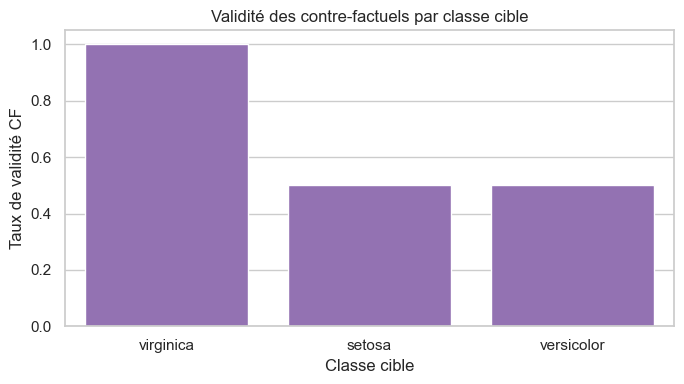

In [10]:
plt.figure(figsize=(7, 4))
sns.barplot(x=valid_by_target.index, y=valid_by_target.values, color='tab:purple')
plt.ylim(0, 1.05)
plt.ylabel('Taux de validité CF')
plt.xlabel('Classe cible')
plt.title('Validité des contre-factuels par classe cible')
plt.tight_layout()
plt.show()

In [11]:
# Présentation détaillée échantillon par échantillon
for idx in sample_indices:
    y_true_i = int(y_test[idx])
    x_orig_raw = X_test_raw[idx]
    print('=' * 110)
    print(f'Sample test idx={idx} | classe vraie={y_true_i} ({class_names[y_true_i]})')
    print('Original:', {f: round(float(v), 3) for f, v in zip(feature_names, x_orig_raw)})

    local_rows = cf_for_all_targets(X_test[idx], y_true_i)
    local_summary = pd.DataFrame([
        {
            'target_class': r['target_class'],
            'target_name': r['target_name'],
            'pred_cf': r['y_pred_cf_name'],
            'valid_cf': r['valid_cf'],
            'l1_raw': round(r['l1_raw'], 4),
        }
        for r in local_rows
    ]).sort_values('target_class')
    display(local_summary)

    for r in local_rows:
        print(f"  -> Cible {r['target_class']} ({r['target_name']}) | pred_cf={r['y_pred_cf_name']} | valid={r['valid_cf']} | l1={r['l1_raw']:.4f}")
        changes = r['changes_df'].copy()
        # On montre les 4 features (Iris) triées par impact.
        changes_show = changes[['feature', 'from', 'to', 'delta', 'abs_delta']]
        display(changes_show)


Sample test idx=41 | classe vraie=0 (setosa)
Original: {'sepal length (cm)': 4.6, 'sepal width (cm)': 3.6, 'petal length (cm)': 1.0, 'petal width (cm)': 0.2}


,target_class,target_name,pred_cf,valid_cf,l1_raw
0,0,setosa,versicolor,False,3.6536
1,1,versicolor,virginica,False,6.1248
2,2,virginica,virginica,True,7.2832


  -> Cible 0 (setosa) | pred_cf=versicolor | valid=False | l1=3.6536


,feature,from,to,delta,abs_delta
2,petal length (cm),1.0,2.623527,1.623527,1.623527
3,petal width (cm),0.2,1.554186,1.354186,1.354186
0,sepal length (cm),4.6,5.000893,0.400893,0.400893
1,sepal width (cm),3.6,3.875025,0.275025,0.275025


  -> Cible 1 (versicolor) | pred_cf=virginica | valid=False | l1=6.1248


...

,feature,from,to,delta,abs_delta
2,petal length (cm),1.3,2.690142,1.390142,1.390142
3,petal width (cm),0.3,1.527723,1.227723,1.227723
0,sepal length (cm),5.0,5.356950,0.356950,0.356950
1,sepal width (cm),3.5,3.695538,0.195538,0.195538


  -> Cible 1 (versicolor) | pred_cf=virginica | valid=False | l1=6.0038


,feature,from,to,delta,abs_delta
2,petal length (cm),1.3,3.974672,2.674672,2.674672
3,petal width (cm),0.3,2.223849,1.923849,1.923849
0,sepal length (cm),5.0,5.816710,0.816710,0.816710
1,sepal width (cm),3.5,4.088571,0.588571,0.588571


  -> Cible 2 (virginica) | pred_cf=virginica | valid=True | l1=7.2234


,feature,from,to,delta,abs_delta
2,petal length (cm),1.3,4.564245,3.264245,3.264245
3,petal width (cm),0.3,2.418369,2.118369,2.118369
0,sepal length (cm),5.0,6.088284,1.088284,1.088284
1,sepal width (cm),3.5,4.252471,0.752471,0.752471
